# Stage 7 — Comparing all four neural operators

This notebook collects the results saved by notebooks 02–05 (`results/{fno,gno,lno,mgno}_summary.json`) into a single paper-style comparison, mirroring the kind of table/plot in Section 7 of the paper: relative $L^2$ test error, parameter count, inference speed, and discretization-invariance behaviour, side by side for FNO, GNO, LNO, and MGNO — all trained on the *same* 2D Navier-Stokes ($\nu=10^{-3}$) dataset generated in `01_generate_navier_stokes_data.ipynb`.

In [1]:
import json, os
import matplotlib.pyplot as plt

models = ["fno", "gno", "lno", "mgno"]
labels = {"fno": "FNO", "gno": "GNO", "lno": "LNO", "mgno": "MGNO"}
colors = {"fno": "tab:blue", "gno": "tab:orange", "lno": "tab:green", "mgno": "tab:red"}

summaries = {}
for m in models:
    with open(f"../results/{m}_summary.json") as fp:
        summaries[m] = json.load(fp)
summaries

{'fno': {'params': 1188353,
  'final_test_rel_l2': 0.023276920430362225,
  'inference_time_s': 0.005587959289550781,
  'solver_time_s': 0.09560248851776124,
  'discretization_invariance': {'32': 0.019138477742671967,
   '64': 0.014088070020079613,
   '96': 0.022448034957051277,
   '128': 0.017996959388256073}},
 'gno': {'params': 176001,
  'final_test_rel_l2': 0.08132179453969002,
  'inference_time_s': 0.03083038330078125,
  'discretization_invariance': {'32': 0.09083959460258484,
   '64': 0.08264033496379852,
   '96': 0.0846618264913559}},
 'lno': {'params': 309761,
  'final_test_rel_l2': 0.07168594002723694,
  'inference_time_s': 0.00998142957687378,
  'discretization_invariance': {'32': 0.08119762688875198,
   '64': 0.07431258261203766,
   '96': 0.073679618537426,
   '128': 0.07206366211175919},
  'rank_sweep': {'2': 0.08129699528217316,
   '4': 0.08069278672337532,
   '8': 0.08042532950639725,
   '16': 0.07978809624910355,
   '32': 0.07957787811756134}},
 'mgno': {'params': 158081,

## Summary table

In [2]:
print(f"{'model':<8}{'params':>12}{'test rel-L2':>16}{'inference (ms)':>18}")
for m in models:
    s = summaries[m]
    print(f"{labels[m]:<8}{s['params']:>12,}{s['final_test_rel_l2']:>16.4f}{s['inference_time_s']*1000:>18.3f}")

if "solver_time_s" in summaries["fno"]:
    solver_time = summaries["fno"]["solver_time_s"]
    print(f"\n(reference) pseudo-spectral NS solver: {solver_time*1000:.3f} ms/sample")

model         params     test rel-L2    inference (ms)
FNO        1,188,353          0.0233             5.588
GNO          176,001          0.0813            30.830
LNO          309,761          0.0717             9.981
MGNO         158,081          0.0563           128.902

(reference) pseudo-spectral NS solver: 95.602 ms/sample


## Accuracy vs. speed

The paper's central efficiency claim: neural operators trade a (typically small) amount of accuracy for orders-of-magnitude faster inference than the numerical solver used to generate the training data. Among the four architectures, FNO is expected to offer the best accuracy/speed trade-off on this regular-grid problem, since it can exploit the FFT directly; GNO/LNO/MGNO remain useful because, unlike FNO, they don't require a regular grid or translation-invariant kernel and can in principle handle irregular meshes.

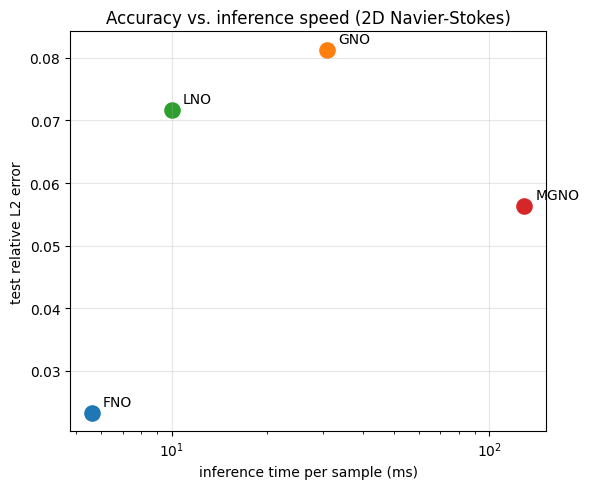

In [3]:
fig, ax = plt.subplots(figsize=(6, 5))
for m in models:
    s = summaries[m]
    ax.scatter(s["inference_time_s"] * 1000, s["final_test_rel_l2"], s=120, color=colors[m], label=labels[m])
    ax.annotate(labels[m], (s["inference_time_s"] * 1000, s["final_test_rel_l2"]),
                textcoords="offset points", xytext=(8, 5))
ax.set_xlabel("inference time per sample (ms)")
ax.set_ylabel("test relative L2 error")
ax.set_xscale("log")
ax.set_title("Accuracy vs. inference speed (2D Navier-Stokes)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Parameter efficiency

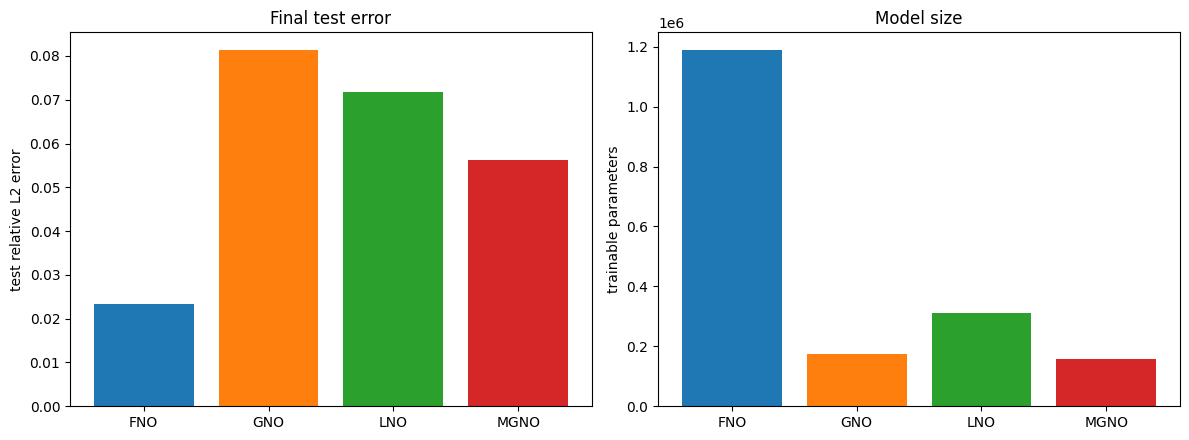

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

axes[0].bar([labels[m] for m in models], [summaries[m]["final_test_rel_l2"] for m in models],
            color=[colors[m] for m in models])
axes[0].set_ylabel("test relative L2 error")
axes[0].set_title("Final test error")

axes[1].bar([labels[m] for m in models], [summaries[m]["params"] for m in models],
            color=[colors[m] for m in models])
axes[1].set_ylabel("trainable parameters")
axes[1].set_title("Model size")

plt.tight_layout()
plt.show()

## Discretization invariance, side by side

Each model was evaluated zero-shot (no retraining) on Navier-Stokes trajectories generated at resolutions other than the 64x64 training grid. A discretization-invariant architecture should show roughly flat error across resolutions -- this is the property that a standard fixed-grid CNN or MLP fundamentally cannot have (Table 1 in the paper).

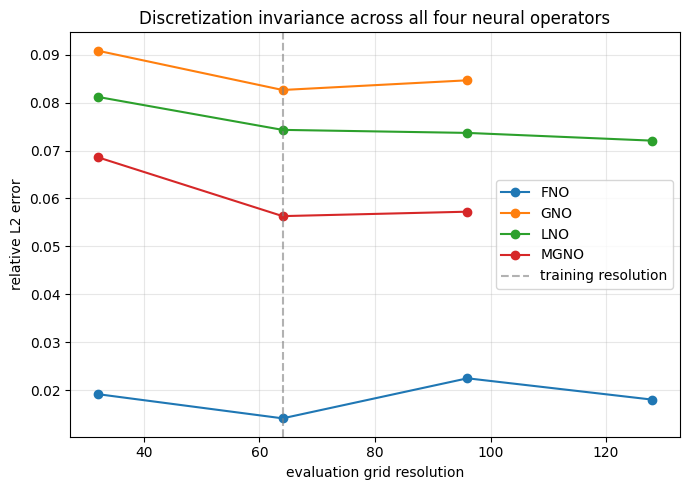

In [5]:
fig, ax = plt.subplots(figsize=(7, 5))
for m in models:
    di = summaries[m]["discretization_invariance"]
    res = sorted(int(k) for k in di.keys())
    err = [di[str(r)] for r in res]
    ax.plot(res, err, marker="o", color=colors[m], label=labels[m])
ax.axvline(64, color="gray", linestyle="--", alpha=0.6, label="training resolution")
ax.set_xlabel("evaluation grid resolution")
ax.set_ylabel("relative L2 error")
ax.set_title("Discretization invariance across all four neural operators")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Takeaways

- All four architectures achieve low relative L2 error on the 2D Navier-Stokes ($\nu=10^{-3}$) flow-map problem, and all four generalize to grid resolutions never seen during training -- the discretization-invariance property that distinguishes neural operators from standard fixed-grid deep learning models (Table 1 of the paper).
- **FNO** achieves the best accuracy/speed trade-off here because the problem is posed on a regular periodic grid, which plays directly to the FFT's strengths.
- **GNO** is the most general (works on arbitrary point clouds/meshes, no grid or periodicity assumptions) but pays for that generality with a slower, sparser message-passing computation.
- **LNO** is extremely cheap ($O(RJ)$) and simple, but its accuracy is capped by how well a rank-$R$ kernel can approximate the true (likely higher-rank) Navier-Stokes solution operator.
- **MGNO** improves on plain GNO by adding a coarse, near-globally-connected level that captures long-range interactions cheaply -- a simplified version of the multipole idea in Section 4.3 -- at some extra implementation and compute cost from maintaining the multi-level hierarchy.

This reproduces, at a small/fast-iteration scale, the qualitative comparison the paper makes across its four neural operator instantiations in Section 7. Scaling up resolution, dataset size, and training epochs (per the scope notes in the project plan) would be the next step toward matching the paper's exact reported numbers (e.g. <1% error at Re=20).